<a href="https://colab.research.google.com/github/ishanwa/Forecasting_project/blob/main/Random_Forest/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import glob, os
import warnings
warnings.filterwarnings("ignore")

In [6]:
data_folder = r"/content"
output_folder = r"/content"

In [7]:
os.makedirs(output_folder, exist_ok=True)
files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))  # Load all revenue center files

In [8]:
def mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


Processing: RevenueCenter_8


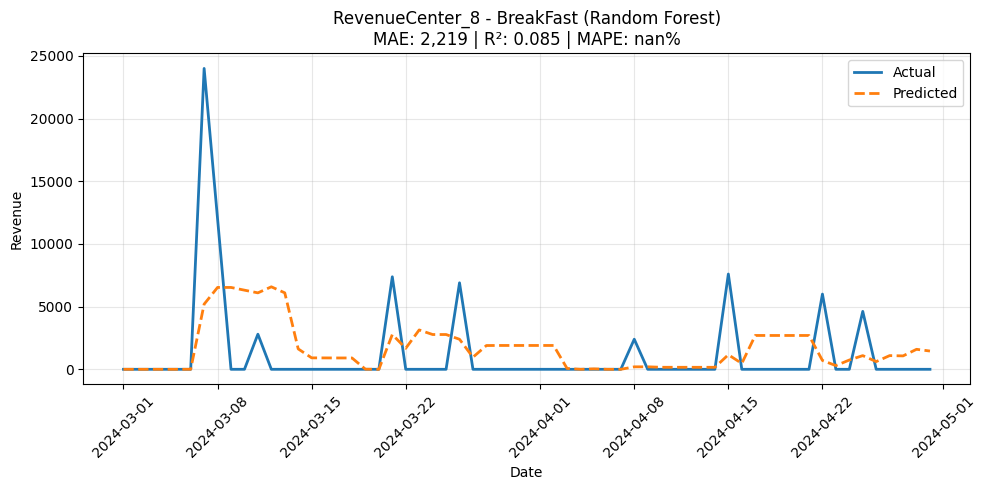

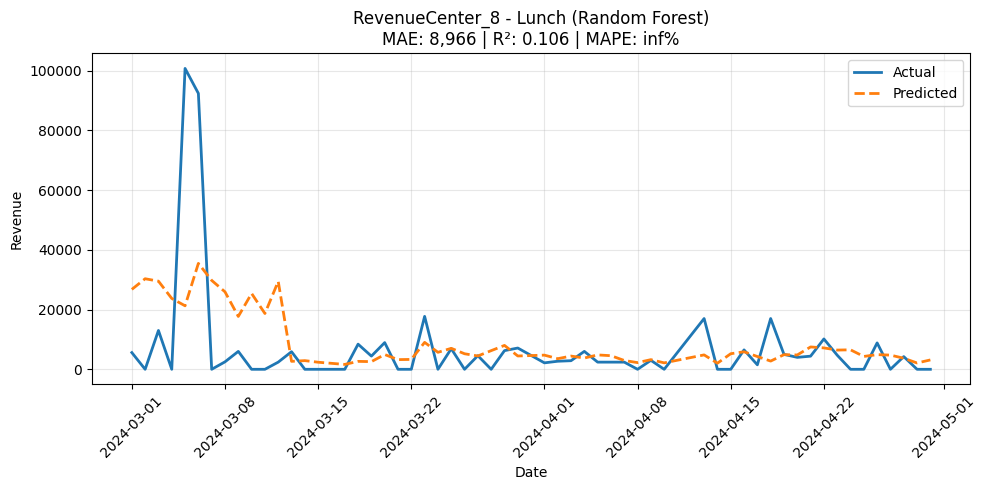

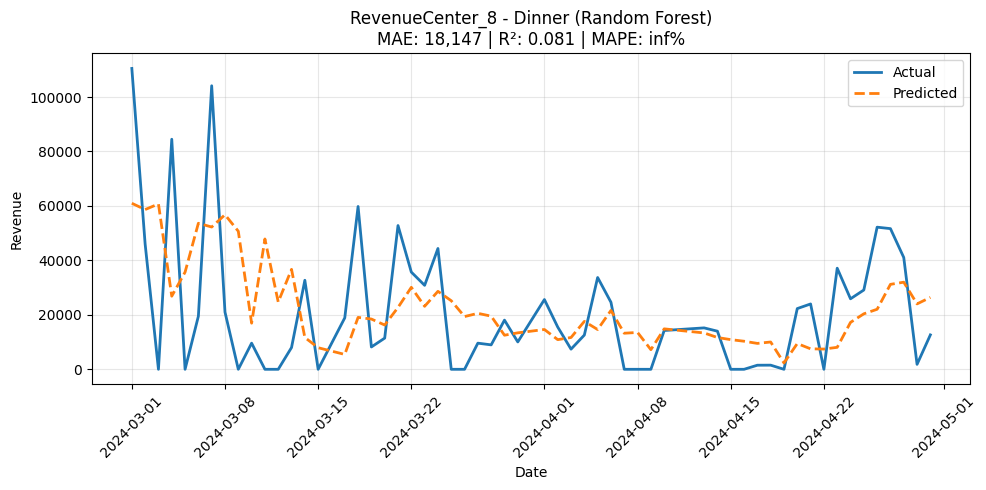

Saved Random Forest results → /content/RevenueCenter_8

Processing: RevenueCenter_7


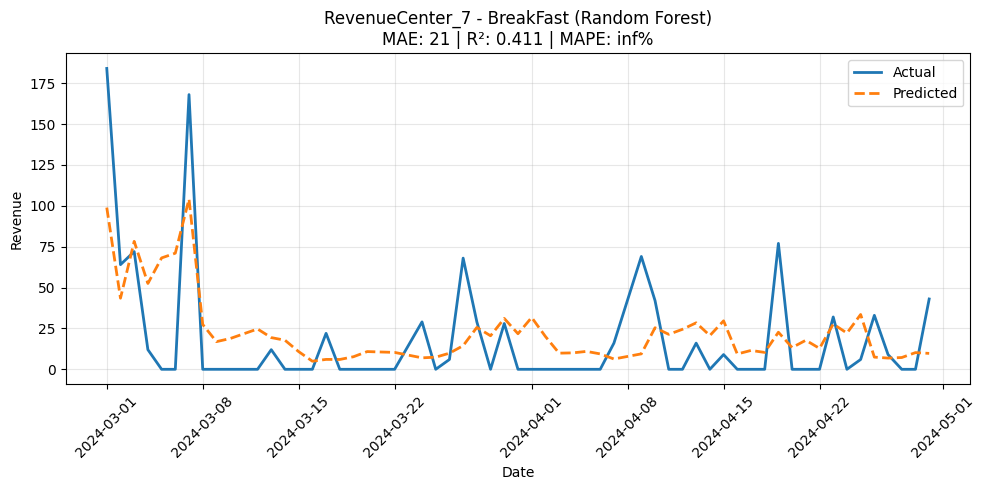

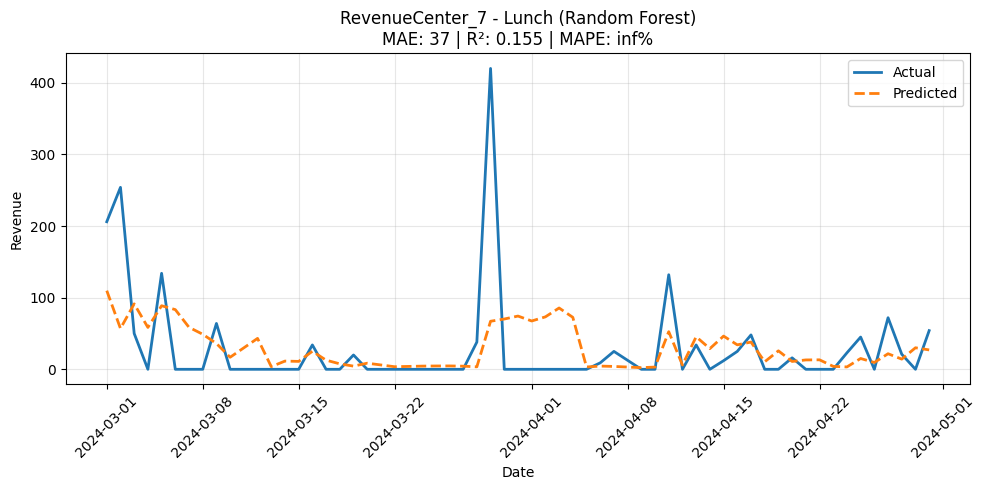

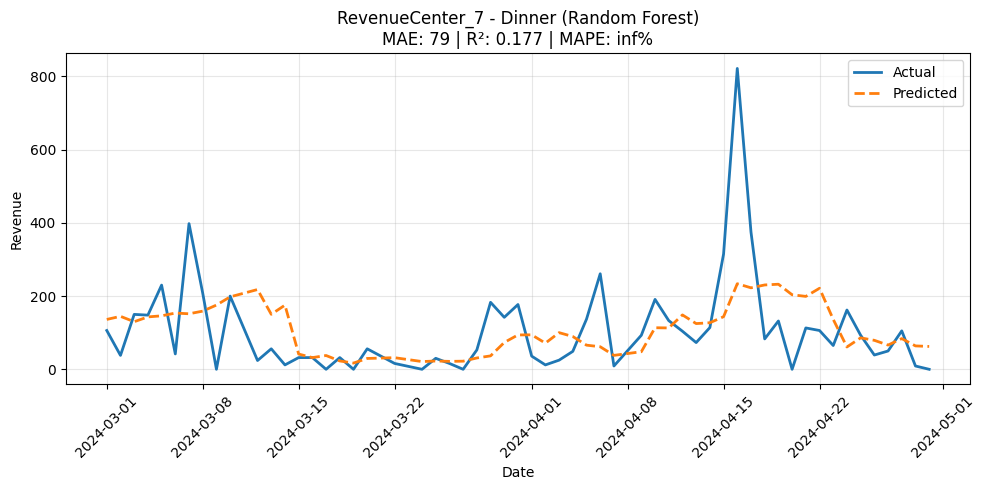

Saved Random Forest results → /content/RevenueCenter_7

Processing: RevenueCenter_4


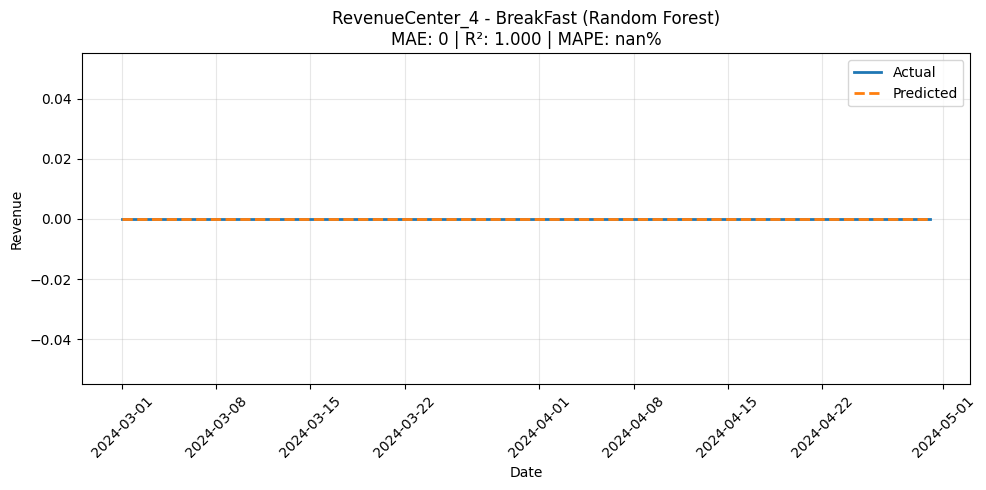

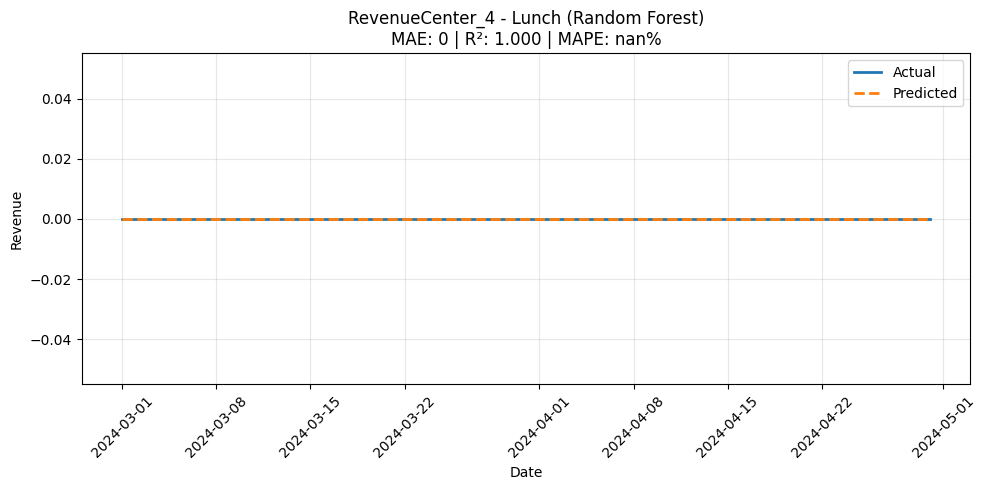

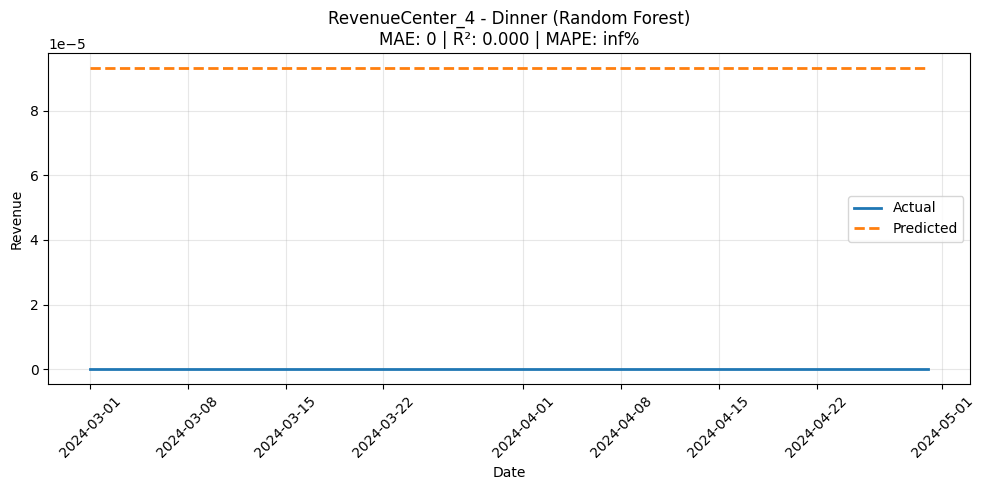

Saved Random Forest results → /content/RevenueCenter_4

Processing: RevenueCenter_1


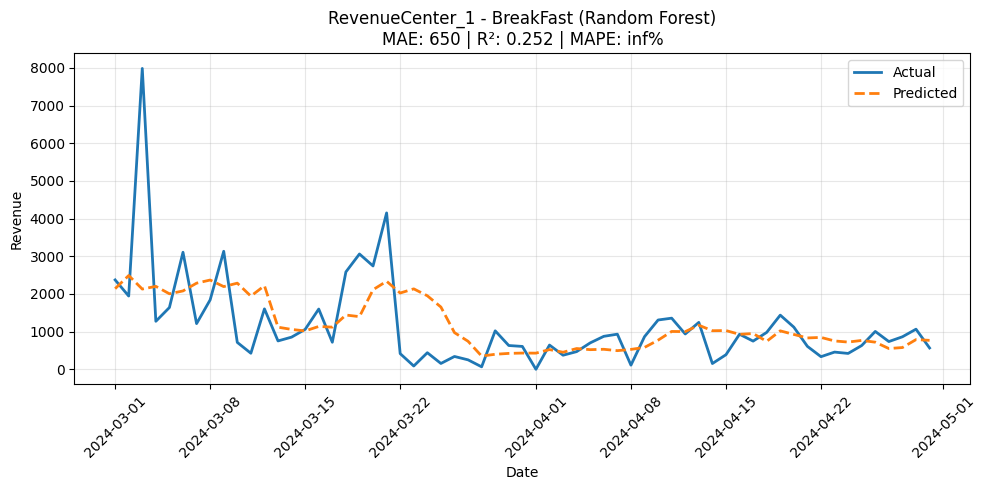

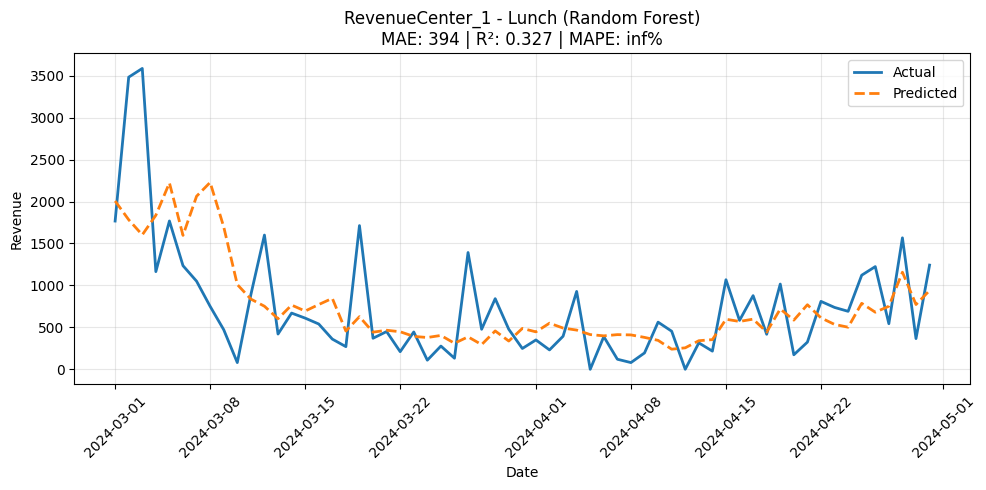

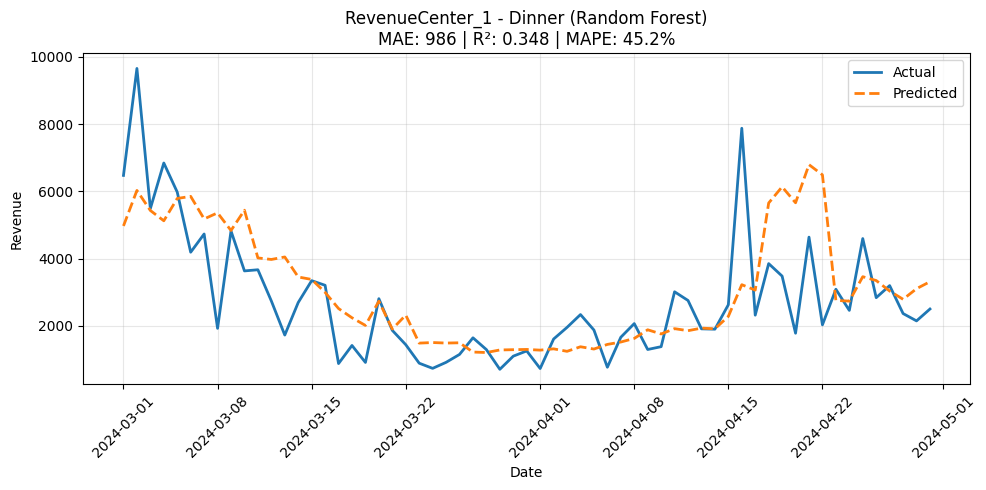

Saved Random Forest results → /content/RevenueCenter_1

Processing: RevenueCenter_5


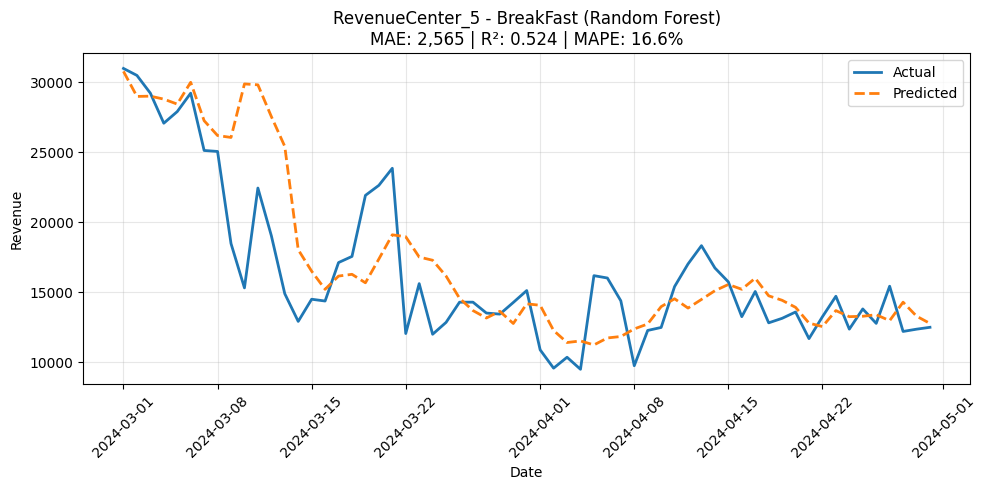

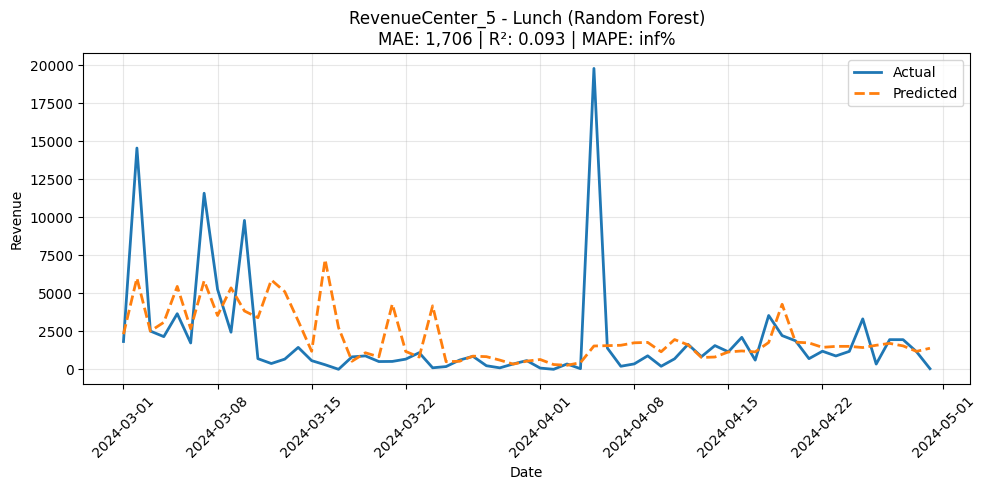

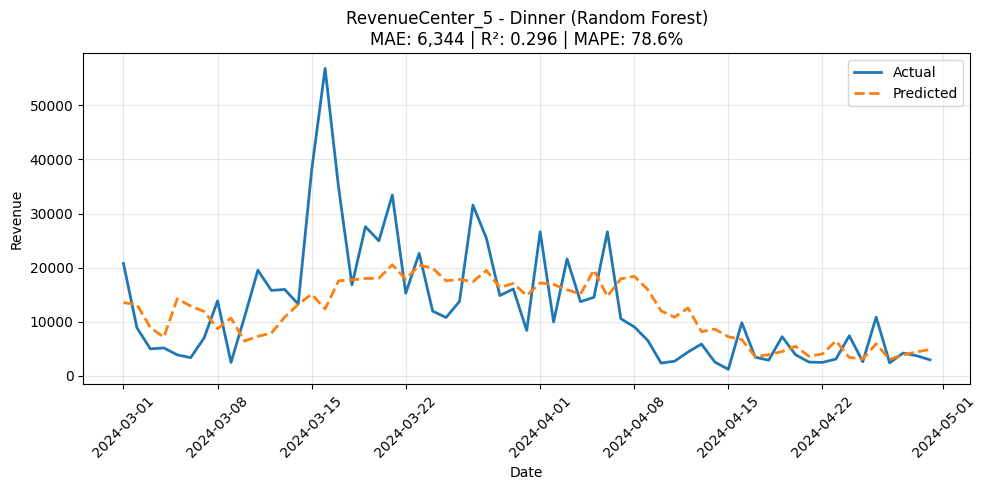

Saved Random Forest results → /content/RevenueCenter_5

Processing: RevenueCenter_9


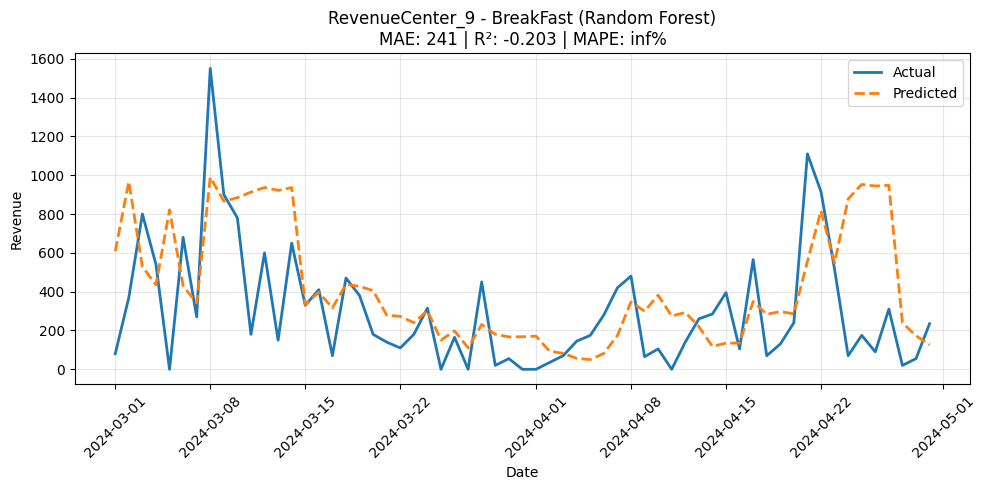

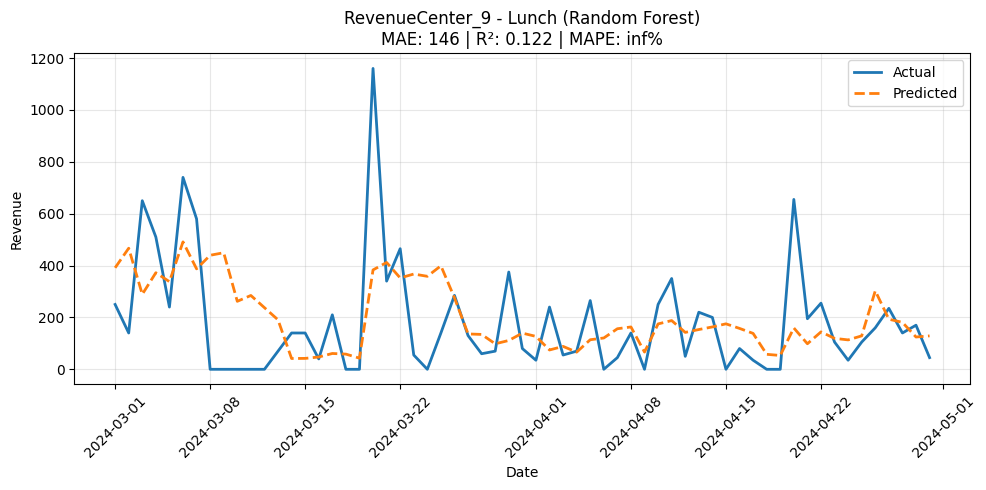

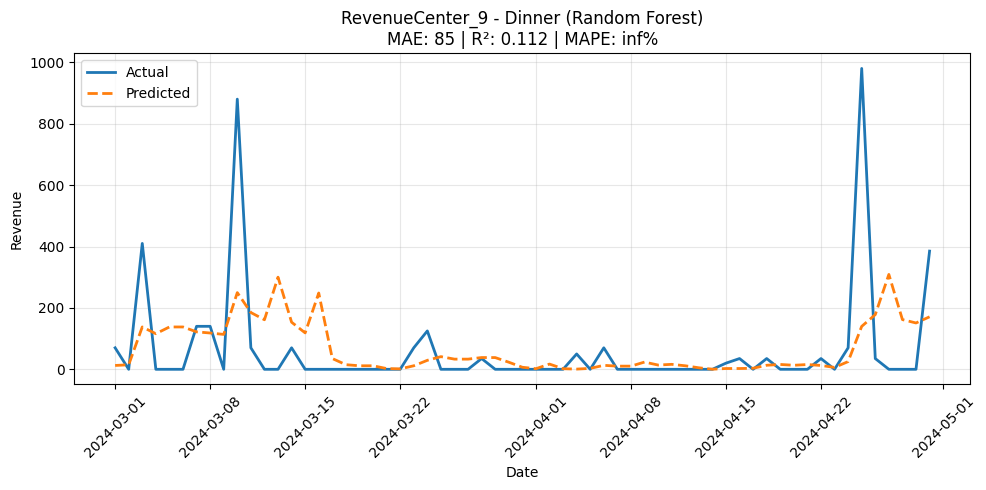

Saved Random Forest results → /content/RevenueCenter_9

Processing: RevenueCenter_6


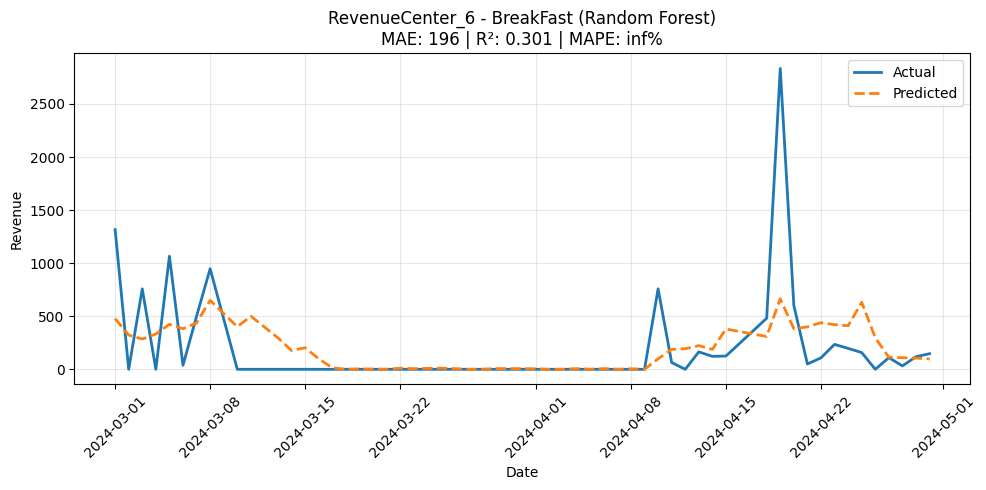

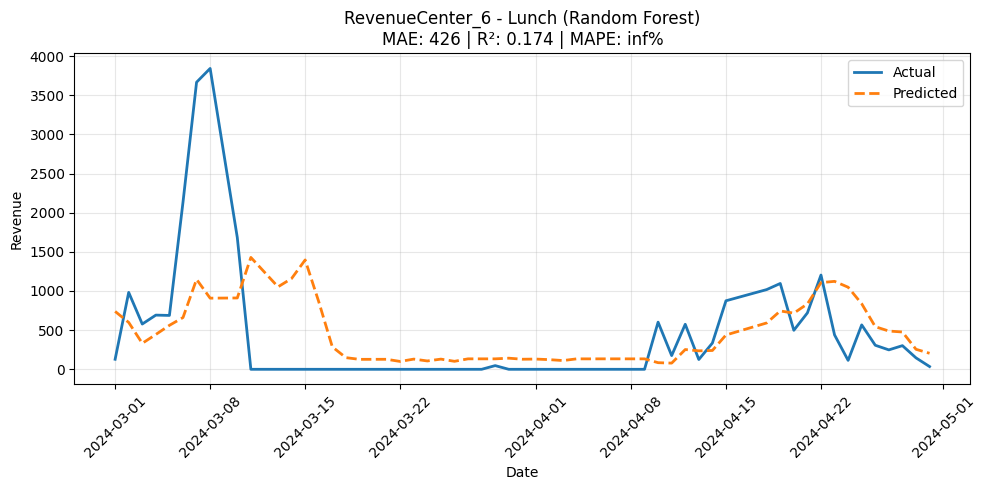

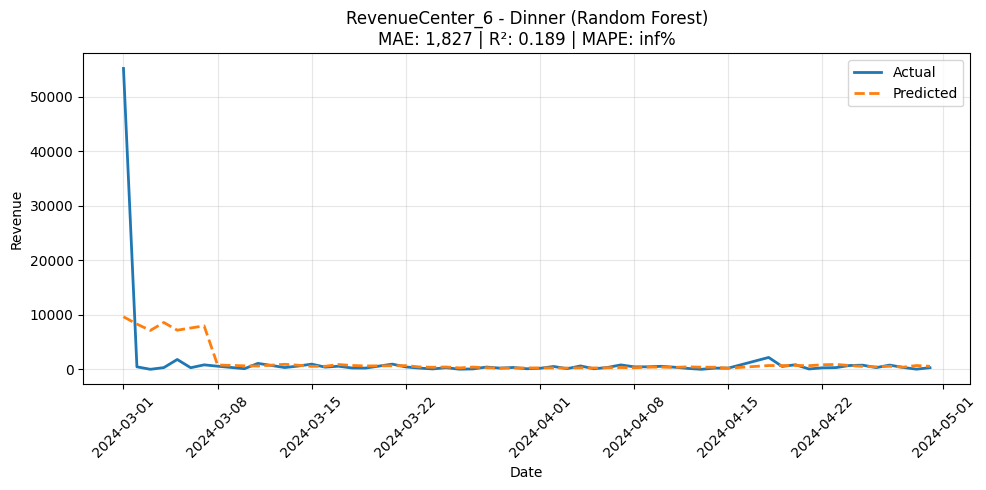

Saved Random Forest results → /content/RevenueCenter_6

Processing: RevenueCenter_3


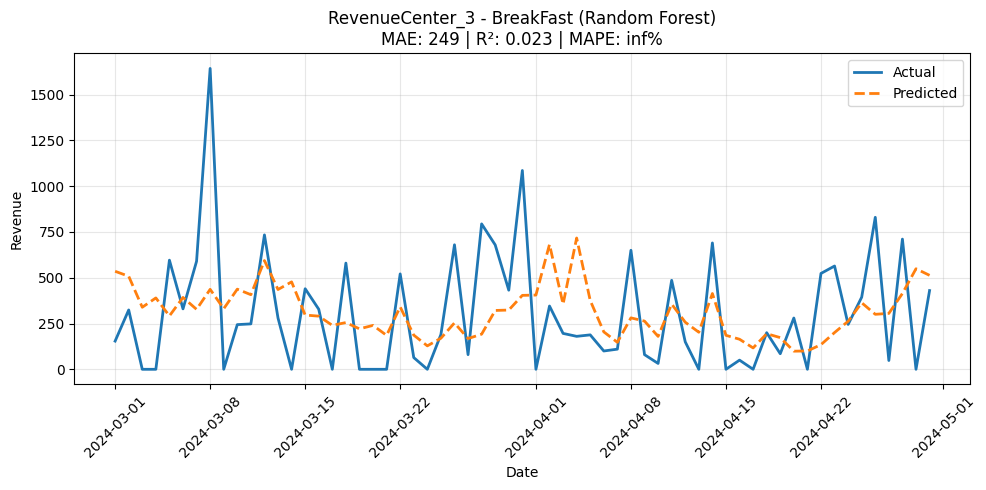

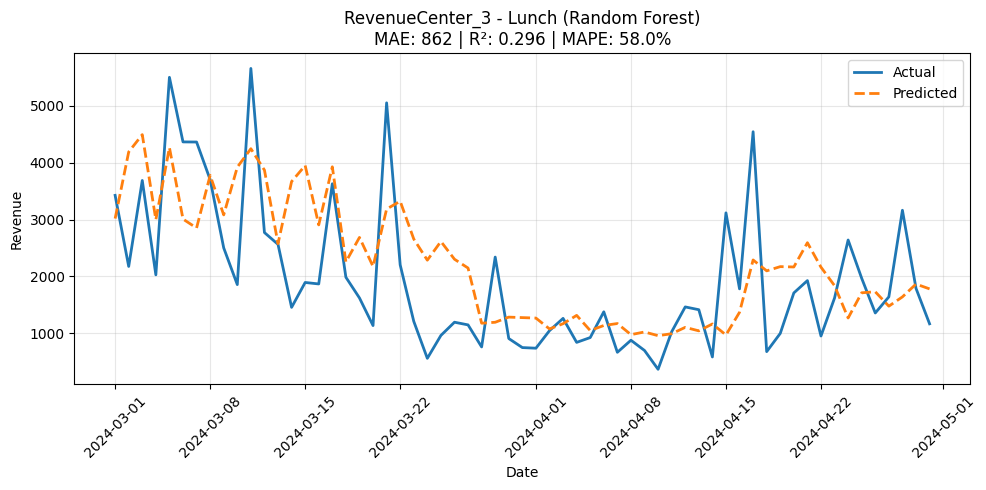

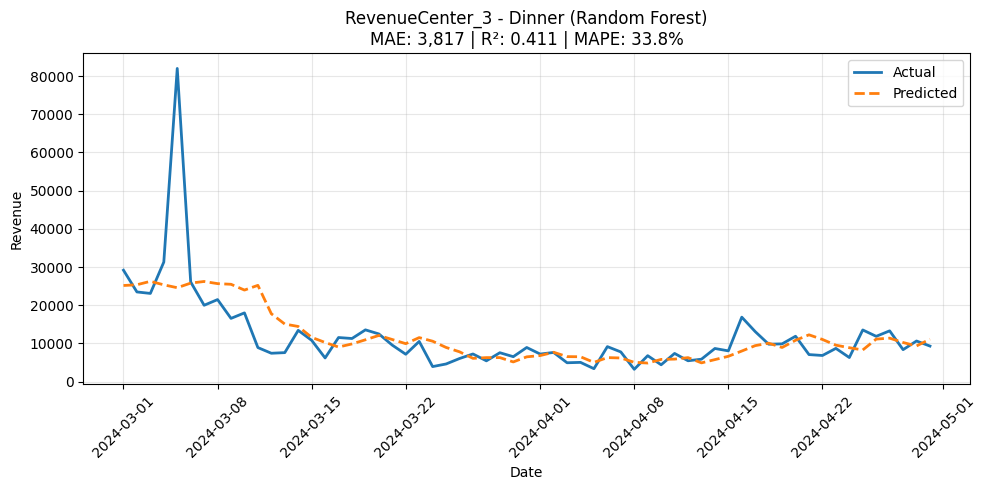

Saved Random Forest results → /content/RevenueCenter_3

Processing: RevenueCenter_2


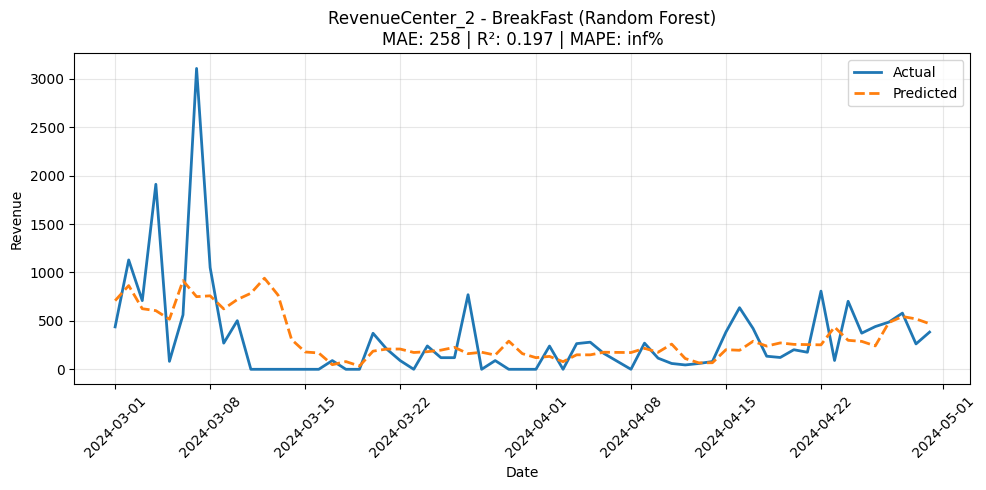

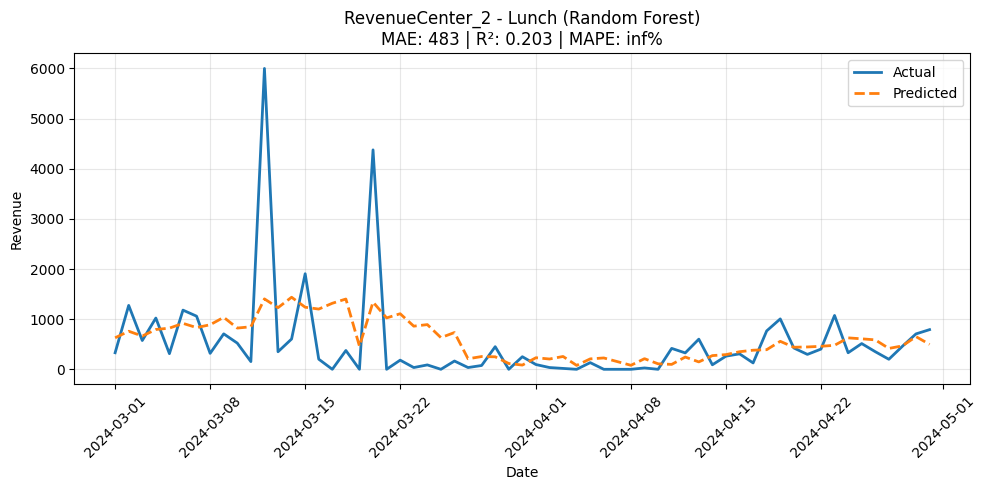

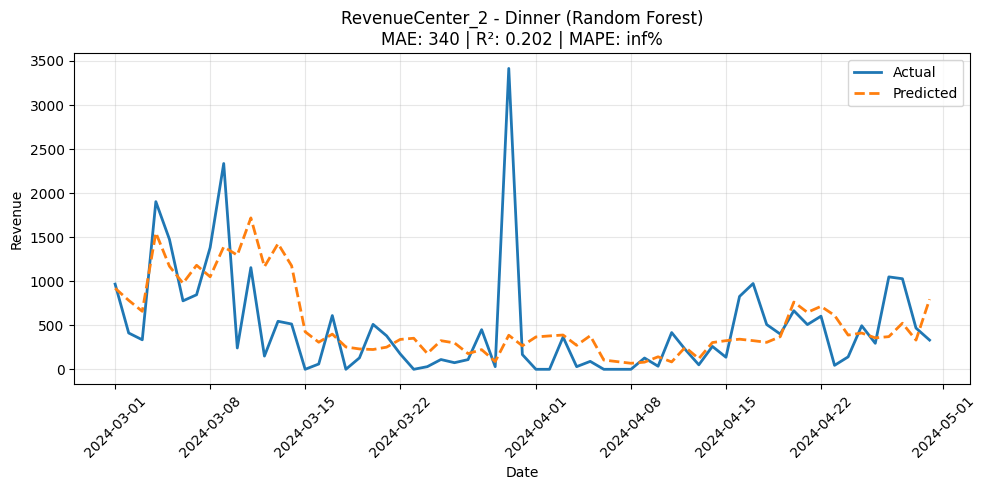

Saved Random Forest results → /content/RevenueCenter_2

ALL REVENUE CENTERS COMPLETED (RANDOM FOREST)


In [9]:
for file in files:
    center_name = os.path.basename(file).replace(".xlsx", "") # Extract revenue center name from file name
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name) # Create a subfolder
    os.makedirs(center_path, exist_ok=True)
    df = pd.read_excel(file)

    df["Date"] = pd.to_datetime(df["Date"])  # Convert Date column to datetime format

    df = df.sort_values("Date").reset_index(drop=True)   # Sort data by date to maintain time order

    split_date = df["Date"].max() - pd.DateOffset(months=2)

    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()   # temporary dataframe for meal

        temp_df.rename(columns={meal: "y"}, inplace=True)

        # Create lag feature
        temp_df["lag_1"] = temp_df["y"].shift(1)
        temp_df["lag_7"] = temp_df["y"].shift(7)
        temp_df["lag_14"] = temp_df["y"].shift(14)
        temp_df["lag_30"] = temp_df["y"].shift(30)

        # crete rolling mean of SAME meal revenue
        temp_df["roll_mean_7"] = temp_df["y"].rolling(7).mean()

        # create rolling standard deviation of SAME meal revenue
        temp_df["roll_std_7"] = temp_df["y"].rolling(7).std()

        temp_df.dropna(inplace=True)  # remove NAN for final df

        # Select training data where date is before or equal to split_date
        train_df = temp_df[temp_df["Date"] <= split_date]

        # Select testing data where date is after split_date
        test_df = temp_df[temp_df["Date"] > split_date]

        # Define input features for training (drop Date and target)
        X_train = train_df.drop(["Date", "y"], axis=1)

        # Define target values for training
        y_train = train_df["y"]

        # Define input features for testing
        X_test = test_df.drop(["Date", "y"], axis=1)

        # Define target values for testing
        y_test = test_df["y"]

        test_dates = test_df["Date"]

        # Initialize Random Forest Regressor model
        rf_model = RandomForestRegressor(
            n_estimators=300,      # Number of trees in the forest
            max_depth=15,          # Maximum depth of each tree
            min_samples_leaf=5,    # Minimum samples required in leaf nodes
            random_state=42,       # Seed for reproducibility
            n_jobs=-1              # Use all CPU cores
        )

        rf_model.fit(X_train, y_train)
        y_pred = rf_model.predict(X_test)

        # Calculate Error
        mae_value = mean_absolute_error(y_test, y_pred)
        r2_value = r2_score(y_test, y_pred)
        mape_value = mape(y_test, y_pred)

        plt.figure(figsize=(10, 5))

        plt.plot(test_dates, y_test, label="Actual", linewidth=2)

        plt.plot(test_dates, y_pred, "--", label="Predicted", linewidth=2)

        # Set plot title including performance metrics
        plt.title(
            f"{center_name} - {meal} (Random Forest)\n"
            f"MAE: {mae_value:,.0f} | "
            f"R²: {r2_value:.3f} | "
            f"MAPE: {mape_value:.1f}%",
            fontsize=12
        )

        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        """
        plot_file = os.path.join(center_path, f"{meal}_random_forest.png")
        plt.savefig(plot_file, dpi=300)
        """
        plt.show()
        plt.close()

    print(f"Saved Random Forest results → {center_path}")
print("\nALL REVENUE CENTERS COMPLETED (RANDOM FOREST)")